## Chapter3 - What to Cover Next?

- Loading and processing data
- Building the model
- Defining the loss function
- Defining the optimizer
- Training and transfer learning
- Deploying the model

STL-10 dataset will be used for demonstration. The images are RGB color with a size of 96*96. The dataset contains 5,000 training images
and 8,000 test images. There are 500 and 800 images per class in the training and test
datasets, respectively.

Labels are:
- Airplane: 0
- Bird: 1
- Car: 2
- Cat: 3
- Deer: 4
- Dog: 5
- Horse: 6
- Monkey: 7
- Ship: 8
- Truck: 9

In [162]:
import torch
from torch.utils.data import Subset, DataLoader
from torchvision import datasets
from torchvision import models
import torchvision.transforms as transforms
from torchvision import utils

from sklearn.model_selection import StratifiedShuffleSplit

import numpy as np
import collections
import os

import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(42)
torch.manual_seed(42)

In [143]:
path2data="./data"

if not os.path.exists(path=path2data):
    os.mkdir(path=path2data)

data_transformer = transforms.Compose([transforms.ToTensor()])
train_ds=datasets.STL10(path2data, split='train', download=True, transform=data_transformer)

print(train_ds.data.shape)

Files already downloaded and verified
(5000, 3, 96, 96)


In [144]:
y_train=[y for _,y in train_ds]
counter_train=collections.Counter(y_train)
print(counter_train)

Counter({1: 500, 5: 500, 6: 500, 3: 500, 9: 500, 7: 500, 4: 500, 8: 500, 0: 500, 2: 500})


In [145]:
test_ds=datasets.STL10(path2data, split='test',download=True,transform=data_transformer)
print(test_ds.data.shape)

Files already downloaded and verified
(8000, 3, 96, 96)


In [146]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

indices=list(range(len(test_ds)))
y_test0=[y for _,y in test_ds]

for test_index, val_index in sss.split(indices,y_test0):
    print("test: {}\ntest lenght: {}".format(test_index,len(test_index)))
    print("val: {}\nval lenght: {}".format(val_index,len(val_index)))

test: [ 369 4826 7056 ... 1150 6669  351]
test lenght: 6400
val: [4311 4042 1350 ...  703   97 4926]
val lenght: 1600


In [161]:
val_ds=Subset(test_ds,val_index)
test_ds=Subset(test_ds,test_index)

print("# of Validation: ",len(val_ds))
print("# of Test: ",len(test_ds))


# of Validation:  1600
# of Test:  6400


In [148]:
y_test=[y for _,y in test_ds]
y_val=[y for _,y in val_ds]

counter_test=collections.Counter(y_test)
counter_val=collections.Counter(y_val)

print("Test-Number of images per label: ",counter_test)
print("Val-Number of images per label:  ",counter_val)


Test-Number of images per label:  Counter({2: 640, 6: 640, 1: 640, 8: 640, 0: 640, 9: 640, 4: 640, 5: 640, 7: 640, 3: 640})
Val-Number of images per label:   Counter({8: 160, 5: 160, 9: 160, 3: 160, 0: 160, 1: 160, 6: 160, 2: 160, 7: 160, 4: 160})


In [149]:
def show(img, label, color=False):
    npimg=img.numpy()
    
    # Change shape C*H*W to H*W*C 
    npimg_transpose = np.transpose(npimg, (1,2,0))

    if color == False:
        npimg_transpose = npimg_transpose[:,:,0]
        plt.imshow(npimg_transpose, interpolation='nearest', cmap='gray')
    else:
        plt.imshow(npimg_transpose, interpolation='nearest')

    plt.title("Label: "+ str(label))
    plt.show()

In [150]:
# Creating sample images in grid
grid_size = 4
random_indice = np.random.randint(0, len(train_ds), grid_size)
print("Randomly selected image indices: ",random_indice)

x_grid_train = [train_ds[i][0] for i in random_indice]
[print(train_ds[i][1]) for i in random_indice]
y_grid_train = [train_ds[i][1] for i in random_indice]

x_grid_train=utils.make_grid(x_grid_train, nrow=4, padding=2)
print(x_grid_train.shape)

Randomly selected image indices:  [ 860 3772 3092  466]
6
9
0
0
torch.Size([3, 100, 394])


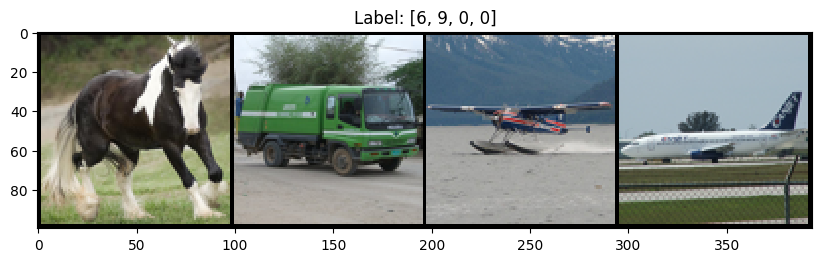

In [151]:
plt.rcParams['figure.figsize'] = (10.0, 5)
show(x_grid_train,y_grid_train, color=True)

In [152]:
meanRGB=[np.mean(x.numpy(),axis=(1,2)) for x,_ in train_ds]
stdRGB=[np.mean(x.numpy(),axis=(1,2)) for x,_ in train_ds]

meanR=np.mean([m[0] for m in meanRGB])
meanG=np.mean([m[1] for m in meanRGB])
meanB=np.mean([m[2] for m in meanRGB])

stdR=np.mean([s[0] for s in stdRGB])
stdG=np.mean([s[1] for s in stdRGB])
stdB=np.mean([s[2] for s in stdRGB])


In [153]:
print("R-Channel mean:{}, std:{}".format(meanR,stdR))
print("G-Channel mean:{}, std:{}".format(meanG,stdG))
print("B-Channel mean:{}, std:{}".format(meanB,stdB))


R-Channel mean:0.44671058654785156, std:0.44671058654785156
G-Channel mean:0.4398098587989807, std:0.4398098587989807
B-Channel mean:0.4066464602947235, std:0.4066464602947235


In [154]:
train_transformer=transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([meanR,meanG,meanB], [stdR,stdG,stdB])
])

In [155]:
test_transformer=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([meanR,meanG,meanB], [stdR,stdG,stdB])
])

In [156]:
train_ds.transform=train_transformer
test_ds.transform=test_transformer

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.4591385].


Image Indices:  [4426 3444 3171 2919]
torch.Size([3, 100, 394])


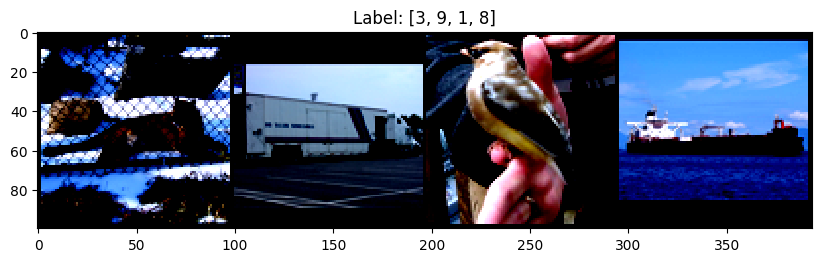

In [157]:
grid_size=4
rnd_inds=np.random.randint(0,len(train_ds),grid_size)
print("Image Indices: ",rnd_inds)

x_grid=[train_ds[i][0] for i in rnd_inds]
y_grid=[train_ds[i][1] for i in rnd_inds]

x_grid=utils.make_grid(x_grid, nrow=4, padding=2)
print(x_grid.shape)

plt.figure(figsize=(10,10))
show(x_grid,y_grid, color=True)


In [158]:
train_dl=DataLoader(train_ds,batch_size=128,shuffle=True)
val_dl=DataLoader(val_ds,batch_size=128,shuffle=False)

for x,y in train_dl:
    print(x.shape)
    print(y.shape)
    break

for x,y in val_dl:
    print(x.shape)
    print(y.shape)
    break

torch.Size([128, 3, 96, 96])
torch.Size([128])
torch.Size([128, 3, 96, 96])
torch.Size([128])


### Building the Models